# Демонстрации к лекции 3: ограничения на картинках и в коде

Ноутбук — для самостоятельной проверки задач семинара (раздел 11 конспекта) после пары: то, что решалось руками у доски, здесь считается кодом. Читается сверху вниз. Разминка и четыре части:

- **(0)** три задачки из повторения (раздел 1 конспекта): три «середины» одних данных, спасатель на пляже, самый большой круг в многоугольнике;
- **(a)** где живёт минимум: ящик из лекции 2 с двумя разными $c$ — безусловный минимум внутри и снаружи, какие грани активны;
- **(b)** множители как баланс сил: $\mu=0.75$ для ящика прямо из $\nabla f(x^\ast)$; для LP планирования — разложение градиента прибыли по нормалям активных ограничений против `res.ineqlin.marginals`; задачи семинара 12.6–12.7 (шар и круг) в коде;
- **(c)** равенство — касание: прямоугольник в круге, $\lambda$ из $\nabla f=\lambda\nabla g$;
- **(d)** сертификат и цена: невязка системы ККТ для ящика и LP; чувствительность $f^\ast(b_2)$ — наклон равен множителю.

Конспект: [`lecture03.md`](lecture03.md). Запуск: `uv run jupyter lab` в корне репозитория.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

BLUE, ORANGE, AQUA, RED, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})
rng = np.random.default_rng(3)

## (0) Разминка: три задачки из повторения

Раздел 1 конспекта. Ничего нового — только то, что было в лекциях 1–2: класс задачи, вспомогательные переменные, выпуклость, условие оптимальности. Каждую задачу решаем солвером и сверяем с ответом «руками».

**Задача А. Три «середины».** Для данных $a=(1,2,3,4,20)$ минимизируем $\sum(x-a_i)^2$, $\sum|x-a_i|$ и $\max_i|x-a_i|$. Первая — QP без ограничений ($f'=0$ даёт среднее), две другие негладкие, но со вспомогательными $s_i\ge\pm(x-a_i)$ становятся LP.

In [2]:
a = np.array([1.0, 2.0, 3.0, 4.0, 20.0])
n = len(a)

# (ii) min sum s_i  при  -s_i <= x - a_i <= s_i ; переменные (x, s_1..s_n)
rows, rhs = [], []
for i in range(n):
    r1 = np.zeros(n + 1); r1[0], r1[1 + i] = 1, -1;  rows.append(r1); rhs.append(a[i])    #  x - s_i <= a_i
    r2 = np.zeros(n + 1); r2[0], r2[1 + i] = -1, -1; rows.append(r2); rhs.append(-a[i])   # -x - s_i <= -a_i
lad = linprog(np.r_[0, np.ones(n)], A_ub=np.array(rows), b_ub=rhs, bounds=[(None, None)] + [(0, None)] * n)

# (iii) min s  при  -s <= x - a_i <= s ; переменные (x, s)
rows = [[1, -1] if k % 2 == 0 else [-1, -1] for k in range(2 * n)]
rhs = [v for ai in a for v in (ai, -ai)]
mm = linprog([0, 1], A_ub=np.array(rows, float), b_ub=rhs, bounds=[(None, None), (0, None)])

print("сумма квадратов -> среднее:          ", a.mean())
print("сумма модулей   -> LP:", lad.x[0].round(6), " np.median:", np.median(a))
print("максимум модуля -> LP:", mm.x[0].round(6), "  середина размаха:", (a.min() + a.max()) / 2)

сумма квадратов -> среднее:           6.0
сумма модулей   -> LP: 3.0  np.median: 3.0
максимум модуля -> LP: 10.5   середина размаха: 10.5


Три разные «середины» одних данных; выброс $20$ тянет среднее и минимакс, медиане он безразличен. Все три задачи выпуклы — найденное является глобальным минимумом.

**Задача Б. Спасатель на пляже.** $T(x)=\sqrt{30^2+x^2}/5+\sqrt{20^2+(40-x)^2}/1.5$ — строго выпукла и растёт на бесконечности, решение существует и единственно; в нём $T'(x^\ast)=0$, что после упрощения — закон Снеллиуса $\sin\theta_1/v_1=\sin\theta_2/v_2$. Формулы для $x^\ast$ нет (уравнение четвёртой степени), число даёт солвер.

x* = 35.303 м,  T* = 22.962 с
закон Снеллиуса: sin1/v1 = 0.152405,  sin2/v2 = 0.152405
для сравнения: по прямой 24.759 с, до траверза и поперёк 23.333 с


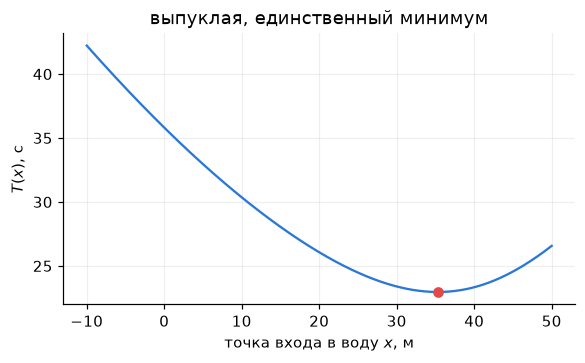

In [3]:
from scipy.optimize import minimize_scalar

a_s, b_w, d, v1, v2 = 30.0, 20.0, 40.0, 5.0, 1.5
T = lambda x: np.sqrt(a_s**2 + x**2) / v1 + np.sqrt(b_w**2 + (d - x)**2) / v2

res = minimize_scalar(T, bounds=(0, d), method="bounded", options=dict(xatol=1e-10))
xs = res.x
sin1, sin2 = xs / np.sqrt(a_s**2 + xs**2), (d - xs) / np.sqrt(b_w**2 + (d - xs)**2)
print(f"x* = {xs:.3f} м,  T* = {res.fun:.3f} с")
print(f"закон Снеллиуса: sin1/v1 = {sin1 / v1:.6f},  sin2/v2 = {sin2 / v2:.6f}")
print(f"для сравнения: по прямой {T(d * a_s / (a_s + b_w)):.3f} с, до траверза и поперёк {T(d):.3f} с")

x = np.linspace(-10, 50, 400)
plt.figure(figsize=(6, 3.2))
plt.plot(x, T(x), color=BLUE); plt.plot(xs, res.fun, "o", color=RED)
plt.xlabel("точка входа в воду $x$, м"); plt.ylabel("$T(x)$, с"); plt.title("выпуклая, единственный минимум")
plt.show()

**Задача В. Самый большой круг в многоугольнике** $\{a_i^\top x\le b_i\}$. Круг $(c,r)$ лежит в полуплоскости $i$ тогда и только тогда, когда $a_i^\top c+r\lVert a_i\rVert\le b_i$ — линейно по $(c,r)$, значит вся задача — LP по трём переменным. Вместе с решением `linprog` возвращает `res.ineqlin.marginals` — по числу на ограничение. Запомните эти числа: к ним вернёмся в частях (b) и (d), когда узнаем, что это такое.

In [4]:
A = np.array([[-1.0, 0.0], [0.0, -1.0], [1.0, 2.0], [3.0, 1.0], [1.0, -1.0]])   # a_i^T x <= b_i
b = np.array([0.0, 0.0, 8.0, 12.0, 3.0])
norms = np.linalg.norm(A, axis=1)

res = linprog([0, 0, -1], A_ub=np.c_[A, norms], b_ub=b, bounds=[(None, None), (None, None), (0, None)])
c_, r_ = res.x[:2], res.x[2]
mu = -res.ineqlin.marginals          # знак: linprog минимизирует -r, см. часть (c)
print("центр c* =", c_.round(4), " радиус r* =", r_.round(4), " (6 - 2*sqrt(5) =", (6 - 2 * np.sqrt(5)).round(4), ")")
print("зазор по ограничениям b - A c - r|a|:", res.slack.round(4), " -> активны", np.where(res.slack < 1e-9)[0] + 1)
print("marginals:", mu.round(4))
print("сумма mu_i a_i =", (mu @ A).round(6), "   сумма mu_i |a_i| =", (mu @ norms).round(6))

центр c* = [1.5279 1.5279]  радиус r* = 1.5279  (6 - 2*sqrt(5) = 1.5279 )
зазор по ограничениям b - A c - r|a|: [0.     0.     0.     1.057  0.8393]  -> активны [1 2 3]
marginals: [0.191 0.382 0.191 0.    0.   ]
сумма mu_i a_i = [0. 0.]    сумма mu_i |a_i| = 1.0


Круг касается трёх сторон (1, 2, 3) — они активны, у них множители положительны; у сторон 4 и 5 зазор положителен и множители **нулевые**. Это комплементарная нежёсткость (раздел 4 конспекта) в чистом виде; а равенства $\sum_i\mu_i a_i=0$ и $\sum_i\mu_i\lVert a_i\rVert=1$ — баланс сил по $(c,r)$ (раздел 6, упражнение 12.4). Пока — просто наблюдение: «круг держат те стороны, которых он касается».

## (a) Где живёт минимум: внутри или на границе

Ящик $[-1,1]^2$ и $f(x)=\tfrac12 x^\top Qx+c^\top x$, $Q=\begin{pmatrix}2&0.5\\0.5&1\end{pmatrix}$ (раздел 2 конспекта). Сравним **безусловный** минимум $\hat x=-Q^{-1}c$ с решением задачи с `bounds` для двух разных $c$: когда $\hat x$ внутри ящика, он и есть ответ; когда снаружи — решение на границе, и часть граней становится активной.

In [5]:
Q = np.array([[2.0, 0.5], [0.5, 1.0]])
Qinv = np.linalg.inv(Q)
bounds = [(-1, 1), (-1, 1)]

def solve_box(c):
    f = lambda x: 0.5 * x @ Q @ x + c @ x
    x_free = -Qinv @ c
    xstar = minimize(f, x0=np.zeros(2), jac=lambda x: Q @ x + c, method="L-BFGS-B", bounds=bounds).x
    h = np.array([1 - xstar[0], 1 + xstar[0], 1 - xstar[1], 1 + xstar[1]])     # h_i >= 0
    return x_free, xstar, h

for c in (np.array([-1.0, -0.5]), np.array([-3.0, -1.0])):
    x_free, xstar, h = solve_box(c)
    inside = np.all(np.abs(x_free) <= 1)
    print(f"c = {c}: безусловный минимум {x_free.round(3)} -> {'внутри ящика' if inside else 'СНАРУЖИ'}")
    print(f"      решение с bounds {xstar.round(3)},  h(x*) = {h.round(3)},  активны грани: {np.where(np.isclose(h, 0))[0] + 1}")
    print(f"      grad f(x*) = {(Q @ xstar + c).round(3)}  {'= 0, как без ограничений' if inside else '!= 0: стенка держит'}\n")

c = [-1.  -0.5]: безусловный минимум [0.429 0.286] -> внутри ящика
      решение с bounds [0.429 0.286],  h(x*) = [0.571 1.429 0.714 1.286],  активны грани: []
      grad f(x*) = [-0.  0.]  = 0, как без ограничений

c = [-3. -1.]: безусловный минимум [1.429 0.286] -> СНАРУЖИ
      решение с bounds [1.  0.5],  h(x*) = [0.  2.  0.5 1.5],  активны грани: [1]
      grad f(x*) = [-0.75  0.  ]  != 0: стенка держит



Первый случай — раздел 2 (а): $\nabla f(x^\ast)=0$, множители не нужны. Второй — (б): решение на грани $x_1=1$, и $\nabla f(x^\ast)=(-0.75,\,0)\ne0$. Что это за $-0.75$ — часть (b).

## (b) Множители как баланс сил

**Одна стенка** (раздел 3). У активной грани $x_1\le1$, то есть $h_1=1-x_1$, нормаль $\nabla h_1=(-1,0)$ смотрит внутрь ящика. В решении тяга $-\nabla f$ должна смотреть точно наружу, значит $\nabla f(x^\ast)=\mu_1\nabla h_1$ — и $\mu_1$ читается прямо из первой координаты градиента.

grad f(x*) = [-0.75  0.  ]   активные грани: [1]
mu = [0.75 0.   0.   0.  ]  -> все >= 0, у неактивных нули
проверка баланса: grad f - sum mu_i grad h_i = [0. 0.]

в точке (1, -0.5): grad f = [-1.25 -1.  ]  -> составляющая вдоль стенки -1.0 != 0: можно скользить, не оптимум


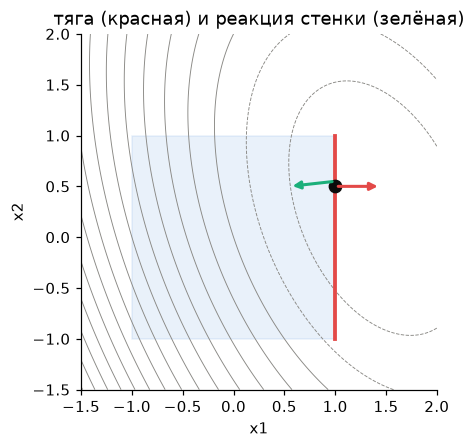

In [6]:
c = np.array([-3.0, -1.0])
x_free, xstar, h = solve_box(c)
grad_f = Q @ xstar + c
grad_h = np.array([[-1, 0], [1, 0], [0, -1], [0, 1]], float)     # нормали граней h = (1-x1, 1+x1, 1-x2, 1+x2)
active = np.isclose(h, 0)

mu = np.zeros(4)
mu[active] = np.linalg.lstsq(grad_h[active].T, grad_f, rcond=None)[0]   # grad f = sum mu_i grad h_i по активным
print("grad f(x*) =", grad_f.round(4), "  активные грани:", np.where(active)[0] + 1)
print("mu =", mu.round(4), " -> все >= 0, у неактивных нули")
print("проверка баланса: grad f - sum mu_i grad h_i =", (grad_f - mu @ grad_h).round(10))

# для сравнения: неоптимальная точка на той же грани
xbad = np.array([1.0, -0.5])
gb = Q @ xbad + c
print("\nв точке (1, -0.5): grad f =", gb.round(3), " -> составляющая вдоль стенки", gb[1].round(3), "!= 0: можно скользить, не оптимум")

fig, ax = plt.subplots(figsize=(4.8, 4.2))
xs = np.linspace(-1.5, 2.0, 200); X1, X2 = np.meshgrid(xs, xs)
F = 0.5 * (Q[0, 0] * X1**2 + 2 * Q[0, 1] * X1 * X2 + Q[1, 1] * X2**2) + c[0] * X1 + c[1] * X2
ax.contour(X1, X2, F, levels=16, colors=[GRAY], linewidths=0.6)
ax.add_patch(plt.Rectangle((-1, -1), 2, 2, color=BLUE, alpha=0.1))
ax.plot([1, 1], [-1, 1], color=RED, lw=2.5)
ax.plot(*xstar, "o", color=INK, ms=8)
ax.annotate("", xy=xstar - 0.6 * grad_f, xytext=xstar, arrowprops=dict(arrowstyle="-|>", color=RED, lw=2))     # тяга -grad f
ax.annotate("", xy=xstar + 0.6 * mu @ grad_h, xytext=xstar + [0, 0.05], arrowprops=dict(arrowstyle="-|>", color=AQUA, lw=2))  # реакция
ax.set(aspect="equal", title="тяга (красная) и реакция стенки (зелёная)", xlabel="x1", ylabel="x2"); ax.grid(False)
plt.show()

**Несколько стенок — вершина LP** (раздел 4). Планирование производства: в вершине $(2,6)$ активны ограничения 2 и 3. Градиент прибыли $c=(3,5)$ раскладывается по их внешним нормалям $a_2=(0,2)$, $a_3=(3,2)$ — коэффициенты и есть множители, а `linprog` отдаёт их в `res.ineqlin.marginals` (со знаком минус для задачи на максимум).

In [7]:
A = np.array([[1.0, 0.0], [0.0, 2.0], [3.0, 2.0]])
b = np.array([4.0, 12.0, 18.0])
c_profit = np.array([3.0, 5.0])

res_p = linprog(-c_profit, A_ub=A, b_ub=b, bounds=[(0, None)] * 2, method="highs")
y_marg = -res_p.ineqlin.marginals
slack = b - A @ res_p.x
active_lp = np.isclose(slack, 0)
print("x* =", res_p.x.round(4), " прибыль =", round(-res_p.fun, 4), " активны ограничения:", np.where(active_lp)[0] + 1)

y_force = np.zeros(3)
y_force[active_lp] = np.linalg.solve(A[active_lp].T, c_profit)      # c = sum_i y_i a_i по активным строкам
print("y из разложения градиента:", y_force.round(4))
print("y из marginals:           ", y_marg.round(4), " -> совпадают")
print("комплементарная нежёсткость y_i * запас_i:", (y_marg * slack).round(6))

x* = [2. 6.]  прибыль = 36.0  активны ограничения: [2 3]
y из разложения градиента: [0.  1.5 1. ]
y из marginals:            [0.  1.5 1. ]  -> совпадают
комплементарная нежёсткость y_i * запас_i: [0. 0. 0.]


**Задачи семинара 12.6 и 12.7 в коде.** Проекция $p=(3,4)$ на единичный шар: формула $x^st=p/(1+2\mu)$, $\mu=	frac12(\lVert p
Vert/r-1)=2$. Линейная цель $c=(3,4)$ на круге: $x^st=-c/\lVert c
Vert$, $\mu=\lVert c
Vert/2=2.5$. И знак $
abla h$: для шара $h=r^2-\lVert x
Vert^2$, $
abla h=-2x$ смотрит к центру — внутрь.

In [8]:
p, r = np.array([3.0, 4.0]), 1.0
proj = minimize(lambda x: 0.5 * np.sum((x - p) ** 2), x0=[0, 0], constraints=[{"type": "ineq", "fun": lambda x: r**2 - x @ x}]).x
mu_proj = 0.5 * (np.linalg.norm(p) / r - 1)
print("12.6 проекция: x* =", proj.round(4), " формула p/(1+2mu) =", (p / (1 + 2 * mu_proj)).round(4), " mu =", mu_proj)

c_lin = np.array([3.0, 4.0])
xs_lin = minimize(lambda x: c_lin @ x, x0=[0.1, 0.1], constraints=[{"type": "ineq", "fun": lambda x: 1 - x @ x}]).x
print("12.7 круг:     x* =", xs_lin.round(4), " формула -c/|c| =", (-c_lin / np.linalg.norm(c_lin)).round(4), " mu =", np.linalg.norm(c_lin) / 2)
print("баланс сил: c + mu * 2x =", (c_lin + np.linalg.norm(c_lin) / 2 * 2 * xs_lin).round(6))

12.6 проекция: x* = [0.6 0.8]  формула p/(1+2mu) = [0.6 0.8]  mu = 2.0
12.7 круг:     x* = [-0.6 -0.8]  формула -c/|c| = [-0.6 -0.8]  mu = 2.5
баланс сил: c + mu * 2x = [-1.1e-05  8.0e-06]


## (c) Равенство — касание

Прямоугольник в круге (ДЗ 2, раздел 5 конспекта): $\min -4x_1x_2$ при $g(x)=x_1^2+x_2^2-1=0$, $x\ge0$. Решаем `minimize` с ограничением-равенством, затем проверяем касание: $\nabla f(x^\ast)=\lambda\nabla g(x^\ast)$, знак $\lambda$ любой.

x* = [0.7071 0.7071]  f* = -2.0  (теория: (0.7071, 0.7071), -2)
grad f = [-2.8284 -2.8284]  grad g = [1.4142 1.4142]  lambda = -2.0
остаток grad f - lambda grad g = [-0.  0.]  -> параллельны: касание

в (1,0): grad f = lambda grad g + mu grad h  ->  lambda = 0.0, mu = -4.0 < 0: стенка должна была бы притягивать -> не минимум


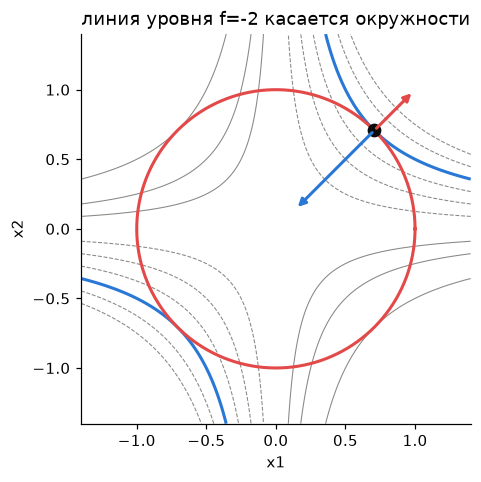

In [9]:
f_rect = lambda x: -4 * x[0] * x[1]
g_circ = lambda x: x[0] ** 2 + x[1] ** 2 - 1
res_eq = minimize(f_rect, x0=[0.9, 0.1], bounds=[(0, 1), (0, 1)], constraints=[{"type": "eq", "fun": g_circ}])
xs_ = res_eq.x
grad_f = np.array([-4 * xs_[1], -4 * xs_[0]])
grad_g = 2 * xs_
lam = (grad_f @ grad_g) / (grad_g @ grad_g)                     # проекция: grad f = lam * grad g
print("x* =", xs_.round(4), " f* =", round(res_eq.fun, 4), " (теория: (0.7071, 0.7071), -2)")
print("grad f =", grad_f.round(4), " grad g =", grad_g.round(4), " lambda =", round(lam, 4))
print("остаток grad f - lambda grad g =", (grad_f - lam * grad_g).round(6), " -> параллельны: касание")

# а точка (1, 0)? там активна ещё стенка x2 >= 0 с нормалью (0, 1)
p = np.array([1.0, 0.0])
gf, gg, gh = np.array([-4 * p[1], -4 * p[0]]), 2 * p, np.array([0.0, 1.0])
lam_p, mu_p = np.linalg.solve(np.c_[gg, gh], gf)
print(f"\nв (1,0): grad f = lambda grad g + mu grad h  ->  lambda = {lam_p:.1f}, mu = {mu_p:.1f} < 0: стенка должна была бы притягивать -> не минимум")

fig, ax = plt.subplots(figsize=(4.8, 4.6))
t = np.linspace(-1.4, 1.4, 300); X1, X2 = np.meshgrid(t, t)
ax.contour(X1, X2, -4 * X1 * X2, levels=[-3, -2.5, -1.5, -1, -0.5, 0.5, 1, 2], colors=[GRAY], linewidths=0.7)
ax.contour(X1, X2, -4 * X1 * X2, levels=[-2.0], colors=[BLUE], linewidths=2, linestyles="solid")
th = np.linspace(0, 2 * np.pi, 300); ax.plot(np.cos(th), np.sin(th), color=RED, lw=2)
ax.plot(*xs_, "o", color=INK, ms=8)
ax.annotate("", xy=xs_ + 0.2 * grad_f, xytext=xs_, arrowprops=dict(arrowstyle="-|>", color=BLUE, lw=2))
ax.annotate("", xy=xs_ + 0.2 * grad_g, xytext=xs_, arrowprops=dict(arrowstyle="-|>", color=RED, lw=2))
ax.set(aspect="equal", title="линия уровня f=-2 касается окружности", xlabel="x1", ylabel="x2"); ax.grid(False)
plt.show()

## (d) Сертификат и цена ограничения

**Сертификат** (раздел 8). Собираем всю систему раздела 6 — стационарность $\nabla_xL=0$, допустимость, $\mu\ge0$, $\mu_ih_i=0$ — и считаем невязки для решения ящика и решения LP. Для выпуклых задач нули означают: решение доказано.

In [10]:
def kkt_residuals(grad_f, grad_h, h, mu):
    return {"стационарность |grad f - sum mu_i grad h_i|": np.abs(grad_f - mu @ grad_h).max(),
            "допустимость min h_i": h.min(),
            "знаки min mu_i": mu.min(),
            "комплементарность max |mu_i h_i|": np.abs(mu * h).max()}

# ящик
x_free, xstar, h = solve_box(c)
mu_box = np.zeros(4); act = np.isclose(h, 0)
mu_box[act] = np.linalg.lstsq(grad_h[act].T, Q @ xstar + c, rcond=None)[0]
print("ящик:")
for k, v in kkt_residuals(Q @ xstar + c, grad_h, h, mu_box).items():
    print(f"   {k:45s} {v: .2e}")

# LP (в форме минимума: f = -c^T x, h = (b - A x, x) >= 0)
x_lp = res_p.x
h_lp = np.r_[b - A @ x_lp, x_lp]
grad_h_lp = np.r_[-A, np.eye(2)]
mu_lp = np.r_[y_marg, -res_p.lower.marginals]          # множители ограничений и границ x >= 0
print("LP:")
for k, v in kkt_residuals(-c_profit, grad_h_lp, h_lp, mu_lp).items():
    print(f"   {k:45s} {v: .2e}")

ящик:
   стационарность |grad f - sum mu_i grad h_i|    0.00e+00
   допустимость min h_i                           0.00e+00
   знаки min mu_i                                 0.00e+00
   комплементарность max |mu_i h_i|               0.00e+00
LP:
   стационарность |grad f - sum mu_i grad h_i|    0.00e+00
   допустимость min h_i                           0.00e+00
   знаки min mu_i                                -0.00e+00
   комплементарность max |mu_i h_i|               0.00e+00


**Цена ограничения** (раздел 7). Меняем мощность второго цеха $b_2$ и смотрим на максимальную прибыль $f^\ast(b_2)$: кусочно-линейная функция, и её наклон около $b_2=12$ равен множителю $y_2^\ast=1.5$. За пределами участка набор активных ограничений меняется — и наклон тоже.

наклон f*(b2) около b2=12: 1.500   множитель y2* = 1.500


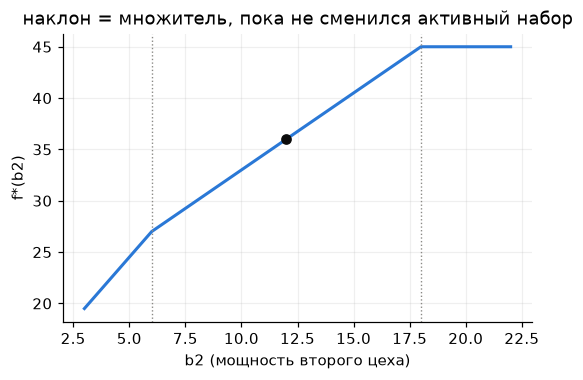

In [11]:
b2s = np.linspace(3, 22, 191)
prof = []
for b2 in b2s:
    r = linprog(-c_profit, A_ub=A, b_ub=[4.0, b2, 18.0], bounds=[(0, None)] * 2, method="highs")
    prof.append(-r.fun)
prof = np.array(prof)
slope_at_12 = (prof[np.searchsorted(b2s, 12.5)] - prof[np.searchsorted(b2s, 11.5)]) / 1.0
print(f"наклон f*(b2) около b2=12: {slope_at_12:.3f}   множитель y2* = {y_marg[1]:.3f}")

plt.figure(figsize=(5.5, 3.4))
plt.plot(b2s, prof, color=BLUE, lw=2)
plt.plot(12, 36, "o", color=INK)
for bp in (6, 18): plt.axvline(bp, color=GRAY, ls=":", lw=0.9)
plt.xlabel("b2 (мощность второго цеха)"); plt.ylabel("f*(b2)"); plt.title("наклон = множитель, пока не сменился активный набор")
plt.show()

## Шпаргалка

| Вопрос | Ответ | Инструмент |
|---|---|---|
| решение внутри или на границе? | сравнить безусловный минимум с допустимым множеством; на границе часть $h_i(x^\ast)=0$ — активные | `minimize` с `bounds`/`constraints`, посмотреть $h(x^\ast)$ |
| что такое множитель? | сила реакции стенки: $\nabla f=\sum\mu_i\nabla h_i+\sum\lambda_j\nabla g_j$, $\mu\ge0$; и цена: $\partial f^\ast/\partial b_i$ | линейная система по активным ограничениям |
| какие ограничения держат? | $\mu_i>0$ — держит, $\mu_i=0$ — не при чём (комплементарная нежёсткость) | `res.ineqlin.marginals` в `linprog` |
| как проверить решение солвера? | невязки системы ККТ: стационарность, допустимость, $\mu\ge0$, $\mu_ih_i=0$ | часть (d) |
| множитель равенства | знак любой: кривая держит с обеих сторон | $\nabla f=\lambda\nabla g$ |

Три типичные ошибки:

1. **Перепутать направление $\nabla h$.** При записи $h(x)\ge0$ градиент $\nabla h$ смотрит *внутрь* допустимого множества; антиградиент цели в оптимуме — *наружу*. Отсюда $\mu\ge0$; при $\mu<0$ вы, скорее всего, записали ограничение с обратным знаком.
2. **Забыть комплементарность.** Решать систему $\nabla f=\sum\mu_i\nabla h_i$ по *всем* ограничениям нельзя — только по активным; у остальных $\mu_i=0$ обязательно.
3. **Считать множитель глобальной ценой.** $\partial f^\ast/\partial b_i=\mu_i^\ast$ верно, пока не сменился набор активных ограничений; при большом изменении $b_i$ наклон другой.